<!-- #region -->
:::{admonition} Run this notebook yourself!
:class: important

Download the executed notebook: **{nb-download}`adversarial_examples_mad.ipynb`**!

Run it in your browser: **{binder}`adversarial_examples_mad.ipynb`**!

:::

(adversarial_examples)=
# Generate adversarial examples using MAD Competition

:::{warning}
This notebook requires the optional dependency `torchvision`, which can be installed with `pip`.
:::

In this notebook we demonstrate how we can use the {class}`~plenoptic.MADCompetition` class to synthesize adversarial examples. Adversarial examples are tiny perturbations to an image that causes Deep Neural Networks to misclasify ([Goodfellow et al., 2015](https://arxiv.org/abs/1412.6572)). MAD competition is used to falsify metrics/models of human perception by generating a pair of images that have the same value for the reference metric but extremal values (highest and lowest) for the optimized metric and testing human sensitivity to this pair of images. In this notebook we demonstrate a different use of the {class}`~plenoptic.MADCompetition` class and show how its underlying machinery can be readily used to generate adversarial examples of Deep Neural Networks. At a high level, this is achieved by defining a reference metric in pixel space (the value of which we want to be low) an optimized metric in model representation space (the value of which we want to be high).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

import plenoptic as po

# this notebook uses torchvision, which is an optional dependency. if this import fails,
# install torchvision in your plenoptic environment and restart the notebook kernel.
try:
    import torchvision
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "optional dependency torchvision not found!"
        " please install it in your plenoptic environment "
        "and restart the notebook kernel"
    )


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72

# set seed for reproducibility
po.set_seed(0)

## Prepare model and image for synthesis

In this section, we initialize a plenoptic-compatible model using the weights from {external+torchvision:ref}`TorchVision <models>`. We use the standard ImageNet-trained ResNet50 as our network to attack. You may be also interested in checking out [](deep_nets) for details of choosing layer and preprocessing of the input image, and using models from {external+timm:doc}`timm <models>`.

### Initialize deep neural network and pre-trained weights

First, we download the model weights for ResNet50 trained on [ImageNet-1K](https://en.wikipedia.org/wiki/ImageNet#ImageNet-1K) and initialize the `torchvision` model.

In [2]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
deepnet = torchvision.models.resnet50(weights=weights)

Next, we ensure that our model is in evaluation mode. Many models, including ResNet50, behave differently when in training and evaluation mode. In plenoptic, models are fixed and so we want the evaluation behavior (see [here](remove-grad-doc) for more details):

In [3]:
deepnet.eval();

### Specify preprocessing


We create a separate preprocessing transform, using the specified `mean` and `std` to normalize the input image.

In [4]:
transform = weights.transforms()
norm = torchvision.transforms.Normalize(transform.mean, transform.std)

### Select layer

Next, we specify the layer to target. Because the goal of adversarial examples is misclassification, the simplest choice is the final fully connected layer, containing probabilities for the 1000 categories.

In [5]:
target_layer = "fc"

### Prepare the image

Now, let's prepare the image. The input image needs to be an RGB image with a height and width of 224 pixels. It should probably also be like those found in ImageNet: a single object in the center of the frame that belongs to one of the [image classes](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/). We'll use one of the famous [monkey selfies](https://en.wikipedia.org/wiki/Monkey_selfie_copyright_dispute), and resize it appropriately:

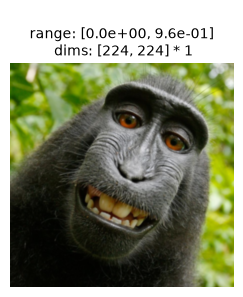

In [6]:
img = po.data.macaque()
# here we downsample the original image by a factor of 4 and then lop off the bottom.
# that way, when we take the central 224 pixels in the following block, we end up with a
# decent image.
img = po.process.blur_downsample(img, 2)[..., :-59, :]
img = po.process.center_crop(img, transform.crop_size[0])
po.plot.imshow(img, as_rgb=True);

###  Last steps
Now we create our model by passing the neural network, target layer, and preprocessing transform to plenoptic's {class}`~plenoptic.models.DeepNetFeatures`:

In [7]:
model = po.models.DeepNetFeatures(deepnet, target_layer, norm)

Finally, let's remove the gradient from all model parameters (as models in plenoptic [are fixed](remove-grad-doc)), convert everything to float64, for [reproducibility](float64-doc), and move everything to `DEVICE`:

In [8]:
img = img.to(DEVICE).to(torch.float64)
model.to(DEVICE).to(torch.float64)
deepnet.to(DEVICE).to(torch.float64)
po.remove_grad(model)

## Visualizing classification of the clean image
First let us extract all the ImageNet categories:

In [9]:
imagenet_categories = np.asarray(weights.meta["categories"])

Let us define two helper functions. `convert_logits_to_probs` converts logits to probabilities that sum to 1. For an input image, `get_category` returns the vector containing the category probabilities and name of the category with the highest probability.

In [10]:
def convert_logits_to_probs(logits):
    return torch.nn.functional.softmax(logits, dim=1).squeeze()


def get_category(image):
    category_probs = convert_logits_to_probs(deepnet(norm(image))).detach().cpu()
    category = imagenet_categories[category_probs.argmax()]
    return category_probs, category

ResNet50 is trained to classify images into one of [1000 categories](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/). The category, [guenon](https://en.wikipedia.org/wiki/Guenon), is an Old World monkey. Though it isn't the actual species of the monkey in question (a [Celebes crested macaque](https://en.wikipedia.org/wiki/Celebes_crested_macaque)), it's a reasonable category for it. Notice the model is also highly confident in its classification (probability of ~0.8)

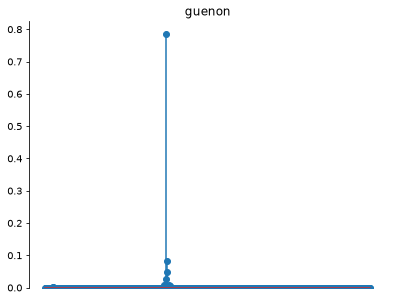

In [11]:
category_probs, category = get_category(img)
po.plot.stem_plot(category_probs, title=category);

## Define optimized and reference metric

To qualify as an adversarial example, the image must satisfy two requirements: (1) the perturbation in image space is small and (2) the model outputting an incorrect classification with high confidence ([Goodfellow et al., 2015](https://arxiv.org/abs/1412.6572)). Conveniently, we already have these two ingredients built into the MAD competition framework. More concretely, if we define the reference metric in pixel space and ask it to not change or minimally change, and define the optimized metric in representation space, in which we make the image representation as far away from the original as possible, we would be able to meet the two requirements and accomplish our goal. For the reference metric, we use the the simple mean-squared-error (MSE).

In [12]:
def reference_metric(x, y):
    return po.metric.mse(x, y).mean()  # .mean() averages across the RGB channels

For the optimized metric, we use the MSE of output logits in the last layer of the network.

In [13]:
def optimized_metric(x, y):
    return po.metric.mse(model(x), model(y))

## Synthesize the adversarial image

We want to maximize {attr}`~plenoptic.MADCompetition.optimized_metric` while holding {attr}`~plenoptic.MADCompetition.reference_metric` fixed. Therefore we set {attr}`~plenoptic.MADCompetition.minmax` to "max". {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` controls the relative weight of {attr}`~plenoptic.MADCompetition.optimized_metric_loss` and {attr}`~plenoptic.MADCompetition.reference_metric_loss` in the objective function. We found a {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` value of 1e10 generally produced good adversarial examples for the monkey image.

In [14]:
mad = po.MADCompetition(
    img, optimized_metric, reference_metric, "max", metric_tradeoff_lambda=1e10
)

:::{admonition} How does {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` affect the adversarial image
:class: dropdown hint

We conducted a hyperparameter search and found increasing {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` led to decrease in both {attr}`~plenoptic.MADCompetition.optimized_metric_loss` and {attr}`~plenoptic.MADCompetition.reference_metric_loss`. This makes intuitive sense as a harsher penalty to keep reference metric loss the same will inevitably come at the cost of the optimized metric loss not increasing (the opposite of what we want). In practise, it would require experimenting with various choices to find the appropriate {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda`

:::

We set the initial noise to be a small value so the initial image is closer to the solution that we want: an image with small deviations in the pixel values from the original but produces large changes in the representation. We also set a custom learning rate value of 0.001 even though you should generally obtain good results with higher or lower learning rates provided the synthesis runs for long enough.

In [15]:
mad.setup(initial_noise=0.001, optimizer_kwargs={"lr": 0.001})

Running the synthesis generates an image that looks just like the original image but we see the optimized metric loss has increased significantly. Even though the reference metric loss measured in pixel space has also increased a little bit, it is not nearly as big as the change in the representation space.

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04242143759531284..0.9751119325944291].


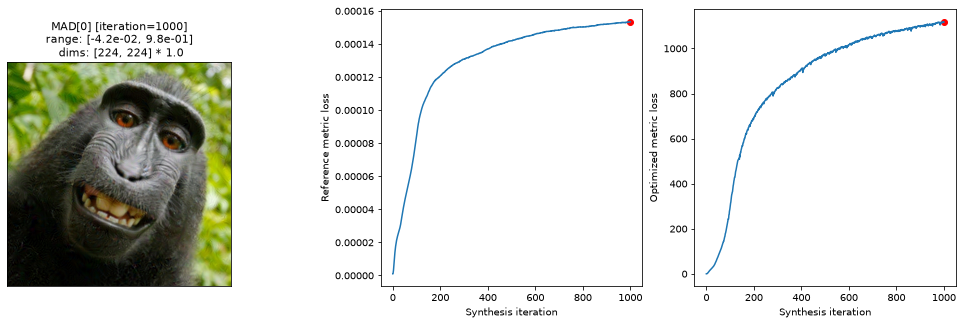

In [16]:
mad.synthesize(1000)
po.plot.synthesis_status(mad);

## Visualizing the adversarial image

Let us compare how the synthesized image compares to the original and initial images. In the bottow row the original image is subtracted to visualize the changes in pixels. There is no change in the left image. In the middle image we see some hardly noticeable noise. In the last image we see a low amount of pixel noise.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00202444759462594..0.9649528578101353].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04242143759531284..0.9751119325944291].


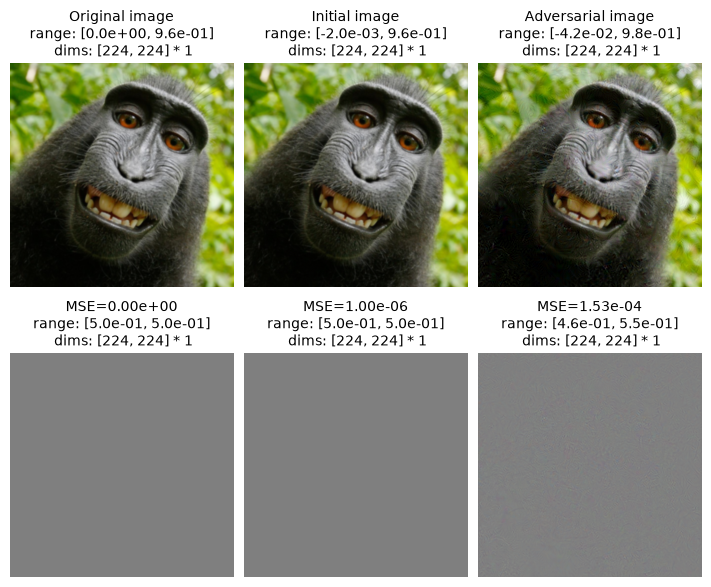

In [17]:
imgs = [img, mad.initial_image, mad.mad_image]
mse = [po.metric.mse(img, i) for i in imgs]
titles = ["Original image", "Initial image", "Adversarial image"]
diffs = [(i + 1) / 2 for i in [img - img, mad.initial_image - img, mad.mad_image - img]]
titles.extend([f"MSE={m.mean().item():.2e}" for m in mse])
imgs.extend(diffs)
po.plot.imshow(imgs, as_rgb=True, title=titles, col_wrap=3);

We can also visualize the difference in each color channel for the initial image (top row) and adversarial image (bottom row).

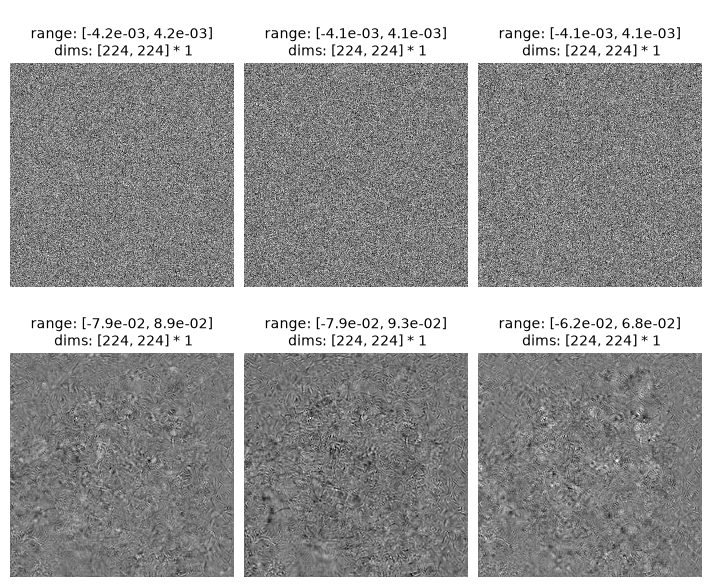

In [18]:
channelwise_diffs = [mad.initial_image - img, mad.mad_image - img]
po.plot.imshow(channelwise_diffs, col_wrap=3);

Finally let us visualize the category probabilities of the original, initial, and advesarial images using stem plots. We see that the network thinks the synthesized image is a burrito with almost 100% certainty! We have successfully generated an adversarial example of the network.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00202444759462594..0.9649528578101353].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04242143759531284..0.9751119325944291].


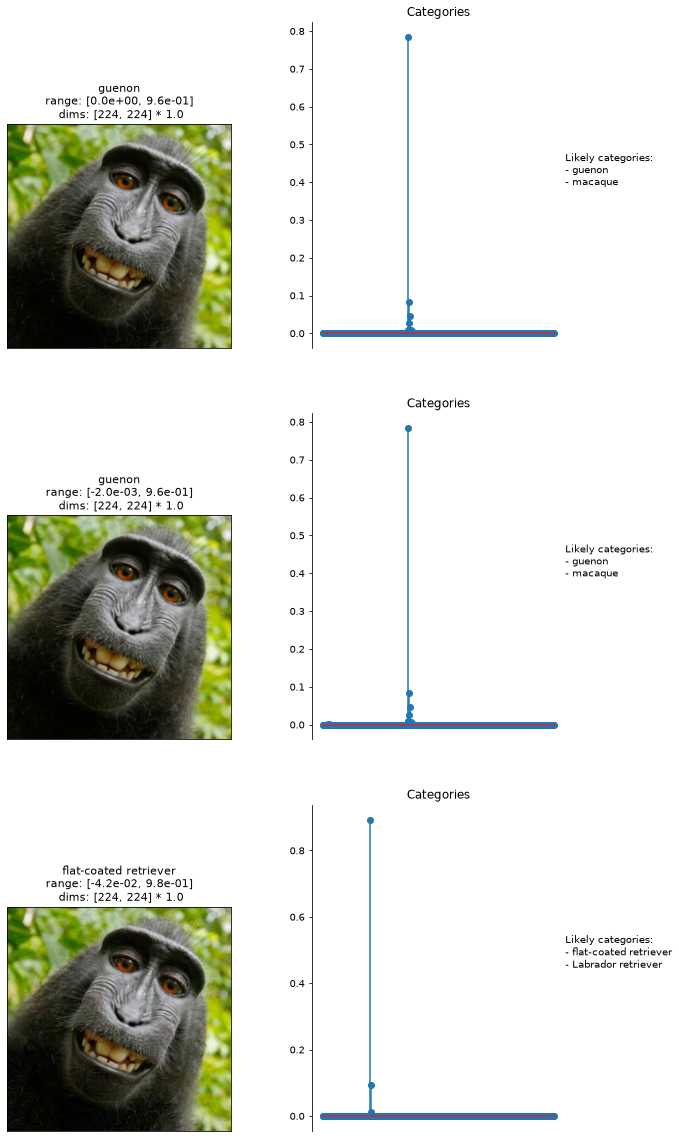

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(10, 20))
for i, img in enumerate([mad.image, mad.initial_image, mad.mad_image]):
    category_probs, category = get_category(img)
    likely_cats = "\n- ".join(list(imagenet_categories[category_probs > 0.05]))
    most_likely_cat = imagenet_categories[category_probs.argmax()]
    po.plot.imshow(img, ax=axes[i, 0], as_rgb=True, title=most_likely_cat)
    po.plot.stem_plot(category_probs, ax=axes[i, 1], ylim=False)
    axes[i, 1].set_title("Categories")
    axes[i, 0].xaxis.set_visible(False)
    axes[i, 0].yaxis.set_visible(False)
    axes[i, 1].text(
        1, 0.5, f"Likely categories:\n- {likely_cats}", transform=axes[i, 1].transAxes
    )

This notebook demonstrates how to generate adversarial examples using the {class}`~plenoptic.MADCompetition` class. We encourage you to experiment with different images and hyperparameters to generate other adversarial examples yourself!
<!-- #endregion -->